# IMPORTS

In [1]:
#import sys
#!{sys.executable} -m pip install torch torchvision torchaudio
#!{sys.executable} -m pip install safetensors

In [2]:
import torch
import torch.nn as nn
from dataset_loader_safetensors import get_dataloaders
from models import build_model
import matplotlib.pyplot as plt

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# CONFIG

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_DIR = "datasets"
BATCH_SIZE = 32
EPOCHS = 30
LR = 5e-4

MODEL_NAME = "nnconv"  # change to "zero" or "gat" or "mlp" or "nnconv"

# LOAD DATA

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    DATASET_DIR,
    batch_size=BATCH_SIZE
)

sample_batch = next(iter(train_loader))
print(sample_batch)
print(sample_batch.x.shape)
print(sample_batch.edge_index.shape)
print(sample_batch.target.shape)

DataBatch(x=[447, 73], edge_index=[2, 554], edge_attr=[554, 7], y=[447, 4], pos=[447, 3], target=[447, 3], obstacles=[1137, 3], obstacle_radii=[1137], formation_id=[32], episode_id=[32], step_idx=[32], num_drones=[32], batch=[447], ptr=[33])
torch.Size([447, 73])
torch.Size([2, 554])
torch.Size([447, 3])


# build model

In [6]:
in_dim = sample_batch.x.shape[1]
print("Input dimension:", in_dim)
model = build_model(MODEL_NAME, in_dim=in_dim).to(DEVICE)

print(model)

Input dimension: 73
NNConvResidualRegressor(
  (edge_mlp1): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2336, bias=True)
  )
  (edge_mlp2): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1024, bias=True)
  )
  (conv1): NNConv(73, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2336, bias=True)
  ))
  (norm1): GraphNorm(32)
  (conv2): NNConv(32, 32, aggr=mean, nn=Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1024, bias=True)
  ))
  (norm2): GraphNorm(32)
  (skip_proj): Linear(in_features=73, out_features=32, bias=True)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(

# loss + optimizer

In [7]:
def compute_loss(pred, target):
    return nn.functional.mse_loss(pred, target)

if MODEL_NAME != "zero":
    optimizer = torch.optim.Adam(model.parameters(), lr=LR,weight_decay=1e-5)

# evaluation function

In [8]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        pred = model(batch)
        loss = compute_loss(pred, batch.target.float())

        num_nodes = batch.x.size(0)
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes

In [9]:
best_val_loss = float("inf")
best_epoch = -1
best_state = None
patience = 5
epochs_without_improvement = 0

train_losses = []
val_losses = []

# training loop

In [10]:

if MODEL_NAME == "zero":
    print("Zero baseline (no training)")

    train_loss = evaluate(train_loader)
    val_loss = evaluate(val_loader)
    test_loss = evaluate(test_loader)

    print("Train:", train_loss)
    print("Val:", val_loss)
    print("Test:", test_loss)

else:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        total_nodes = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()

            pred = model(batch)
            loss = compute_loss(pred, batch.target.float())

            loss.backward()
            optimizer.step()

            num_nodes = batch.x.size(0)
            total_loss += loss.item() * num_nodes
            total_nodes += num_nodes

        train_loss = total_loss / total_nodes
        val_loss = evaluate(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    print("\nBest epoch:", best_epoch)
    print("Best val loss:", best_val_loss)

    model.load_state_dict(best_state)
    model = model.to(DEVICE)

    test_loss = evaluate(test_loader)
    print("Test loss with best model:", test_loss)

Epoch 1 | Train: 0.9033 | Val: 0.8548
Epoch 2 | Train: 0.8935 | Val: 0.8531
Epoch 3 | Train: 0.8889 | Val: 0.8500
Epoch 4 | Train: 0.8854 | Val: 0.8483
Epoch 5 | Train: 0.8833 | Val: 0.8494
Epoch 6 | Train: 0.8815 | Val: 0.8466
Epoch 7 | Train: 0.8803 | Val: 0.8480
Epoch 8 | Train: 0.8794 | Val: 0.8476
Epoch 9 | Train: 0.8782 | Val: 0.8490
Epoch 10 | Train: 0.8775 | Val: 0.8465
Epoch 11 | Train: 0.8769 | Val: 0.8454
Epoch 12 | Train: 0.8761 | Val: 0.8464
Epoch 13 | Train: 0.8754 | Val: 0.8477
Epoch 14 | Train: 0.8750 | Val: 0.8454
Epoch 15 | Train: 0.8745 | Val: 0.8460
Epoch 16 | Train: 0.8737 | Val: 0.8478
Epoch 17 | Train: 0.8735 | Val: 0.8465
Epoch 18 | Train: 0.8729 | Val: 0.8463
Epoch 19 | Train: 0.8725 | Val: 0.8479
Early stopping triggered at epoch 19

Best epoch: 14
Best val loss: 0.8453878176365724
Test loss with best model: 0.8058727113527924


In [11]:
results = {
    "model_name": MODEL_NAME,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "train_losses": train_losses,
    "val_losses": val_losses,
}

print(results)

if MODEL_NAME != "zero" and best_state is not None:
    torch.save(best_state, f"best_{MODEL_NAME}.pt")
    print(f"Saved best model as best_{MODEL_NAME}.pt")

{'model_name': 'nnconv', 'best_epoch': 14, 'best_val_loss': 0.8453878176365724, 'test_loss': 0.8058727113527924, 'train_losses': [0.9032874328075237, 0.8935038170995012, 0.888939035821638, 0.8854443126779497, 0.8832516959721423, 0.8814776056833279, 0.8803165081432284, 0.8794375289645674, 0.8781709306550491, 0.877533449156473, 0.8768683591315236, 0.8761222806736595, 0.8754259384453118, 0.8749804494264625, 0.8744924720265352, 0.8736700490853051, 0.8735075124208228, 0.8728549832647994, 0.8724744218992595], 'val_losses': [0.8548388059953057, 0.8531265193727514, 0.85002816647476, 0.848281708880171, 0.849396163270085, 0.8466226994502447, 0.8479904468467953, 0.8476324850641553, 0.8489772306916522, 0.8465088998412119, 0.8454118525989057, 0.8463777380775926, 0.8476562601920484, 0.8453878176365724, 0.8459705127559758, 0.8477605079836692, 0.846473424561208, 0.8462552734110335, 0.8478736873474917]}
Saved best model as best_nnconv.pt


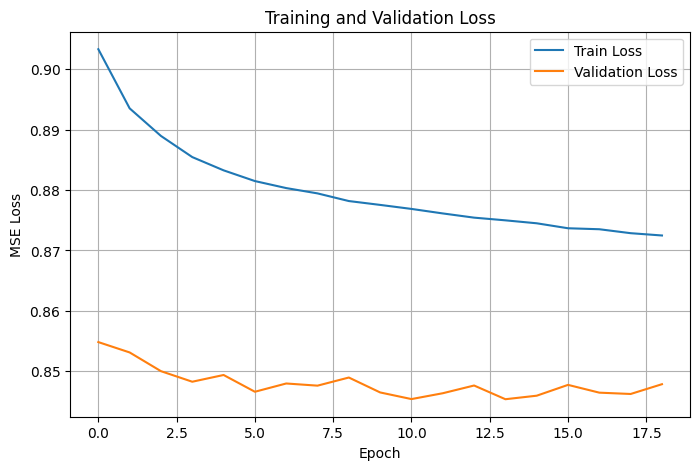

In [12]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.savefig(
    "plots/loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()